<a href="https://colab.research.google.com/github/brunobobadilla06/Practica---Ciencia-de-Datos-I/blob/main/Practica_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clase de visualizacion de Datos con Seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuraciones opcionales para mejor visualizacion
sns.set_style("whitegrid") # Establece un tema estetico para los graficos
plt.rcParams["figure.figsize"] = (12, 6) # Establece un tamaño de figura por defecto
warnings.filterwarnings("ignore") # Ignora advertenciad(util para presentaciones)

In [ ]:


# Reproducibilidad
np.random.seed(42)

regiones = ["Norte", "Sur", "Este", "Oeste"]
productos = ["Producto_A", "Producto_B", "Producto_C"]
meses = pd.date_range("2023-01-01", "2023-12-01", freq="MS")

datos = []

for region in regiones:
    for producto in productos:
        for mes in meses:
            datos.append([
                region,
                producto,
                mes.strftime("%Y-%m"),
                np.random.randint(2000, 5001),          # Ventas
                round(np.random.uniform(3.0, 5.0), 6), # Satisfacción
                np.random.randint(500, 3001)           # Costos
            ])

df = pd.DataFrame(
    datos,
    columns=[
        "Region",
        "Producto",
        "Mes",
        "Ventas",
        "Satisfaccion_Cliente",
        "Costo_Operativo"
    ]
)

# Guardar CSV
df.to_csv("ventas_dataset_actdeclase.csv", index=False)

print("Dataset generado correctamente")
df
#print(df.head())

Dataset generado correctamente


,Region,Producto,Mes,Ventas,Satisfaccion_Cliente,Costo_Operativo
0,Norte,Producto_A,2023-01,2860,3.366870,1595
1,Norte,Producto_A,2023-02,3638,3.891666,1738
2,Norte,Producto_A,2023-03,2330,3.918498,630
3,Norte,Producto_A,2023-04,3685,3.112823,2891
4,Norte,Producto_A,2023-05,3515,4.877105,2933
...,...,...,...,...,...,...
139,Oeste,Producto_C,2023-08,3631,4.712980,1848
140,Oeste,Producto_C,2023-09,2515,4.231702,835
141,Oeste,Producto_C,2023-10,3782,4.888503,1395
142,Oeste,Producto_C,2023-11,4207,4.880460,2187


In [ ]:
#Mostramos info general del dataframe
print('Informacion del DataFrame')
df.info()

Informacion del DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Region                144 non-null    object 
 1   Producto              144 non-null    object 
 2   Mes                   144 non-null    object 
 3   Ventas                144 non-null    int64  
 4   Satisfaccion_Cliente  144 non-null    float64
 5   Costo_Operativo       144 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 6.9+ KB


In [ ]:
# Muestra estadisticas descriptivas para las columnas numericas
print('Estadisticas descriptivas')
df.describe()

Estadisticas descriptivas


,Ventas,Satisfaccion_Cliente,Costo_Operativo
count,144.000000,144.000000,144.000000
mean,3565.569444,4.037237,1777.159722
std,860.697576,0.556588,737.186853
min,2001.000000,3.011044,504.000000
25%,2939.500000,3.669748,1115.500000
50%,3561.000000,4.028393,1804.500000
75%,4335.500000,4.434872,2391.250000
max,4999.000000,4.992507,2989.000000


In [ ]:
# Verifica si hay valores nulos
print('Valores nulos')
df.isnull().sum()

Valores nulos


,0
Region,0
Producto,0
Mes,0
Ventas,0
Satisfaccion_Cliente,0
Costo_Operativo,0


Preparacion de Datos(Si es necesario)


In [ ]:
# Convertir la columna 'Mes' a tipo de DateTime
df['Mes'] = pd.to_datetime(df['Mes'], format='%Y-%m')

# Extraer el mes y el año (Puede ser util para agrupaciones)
df['NumeroMes'] = df['Mes'].dt.month
df['Año'] = df['Mes'].dt.year

# Verificar el cambio en el tipo de dato y las nuevas columnas
print(df.info())

# Mostrar el DataFrame resultante
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Region                144 non-null    object        
 1   Producto              144 non-null    object        
 2   Mes                   144 non-null    datetime64[ns]
 3   Ventas                144 non-null    int64         
 4   Satisfaccion_Cliente  144 non-null    float64       
 5   Costo_Operativo       144 non-null    int64         
 6   NumeroMes             144 non-null    int32         
 7   Año                   144 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(2)
memory usage: 8.0+ KB
None


,Region,Producto,Mes,Ventas,Satisfaccion_Cliente,Costo_Operativo,NumeroMes,Año
0,Norte,Producto_A,2023-01-01,2860,3.366870,1595,1,2023
1,Norte,Producto_A,2023-02-01,3638,3.891666,1738,2,2023
2,Norte,Producto_A,2023-03-01,2330,3.918498,630,3,2023
3,Norte,Producto_A,2023-04-01,3685,3.112823,2891,4,2023
4,Norte,Producto_A,2023-05-01,3515,4.877105,2933,5,2023


Introducción a Seaborn: Tipos de Gráficos Comunes

Seaborn simplifica la creación de gráficos estadísticos complejos. Se integra perfectamente con DataFrames de Pandas. Vamos a explorar algunos tipos de gráficos útiles para nuestro dataset.

3.1. Gráficos de Distribución (Distribution Plots)

Nos ayudan a entender cómo se distribuyen los valores de una variable numérica.

• histplot: Histograma, muestra la frecuencia de valores en intervalos (bins).
• kdeplot: Estimación de Densidad del Kernel, una versión suavizada del histograma.
• displot: Figura-nivel para histogramas y KDEs, permite separar por categorías (col, row, hue).

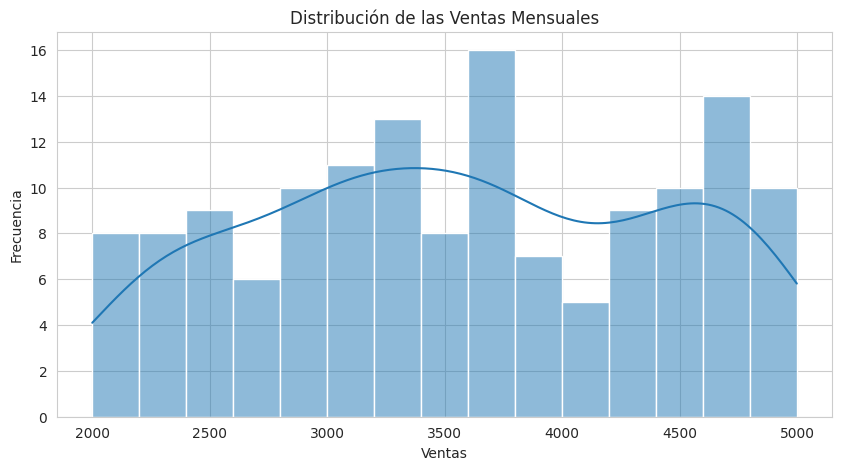

In [ ]:
# Histograma de Ventas
plt.figure(figsize=(10, 5)) # Ajustar tamaño para este gráfico específico
sns.histplot(data=df, x='Ventas', bins=15, kde=True)
plt.title('Distribución de las Ventas Mensuales')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.show()

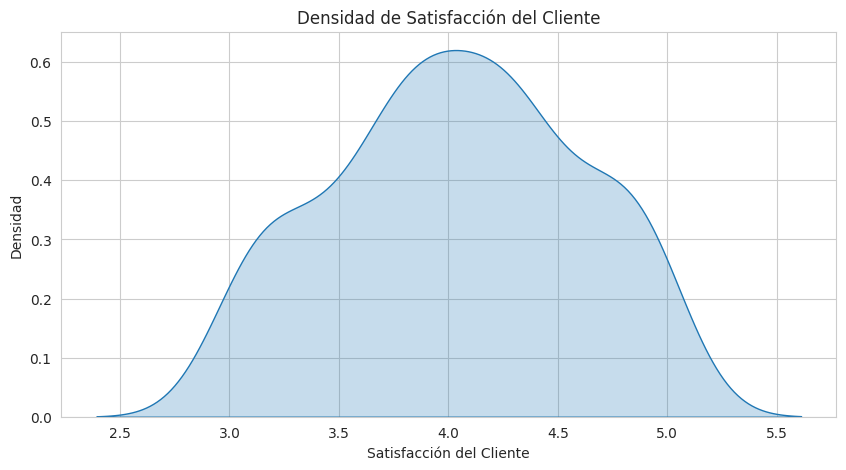

In [ ]:
# KDE plot de satisfaccion del cliente
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Satisfaccion_Cliente', fill=True)
plt.title('Densidad de Satisfacción del Cliente')
plt.xlabel('Satisfacción del Cliente')
plt.ylabel('Densidad')
plt.show()
#

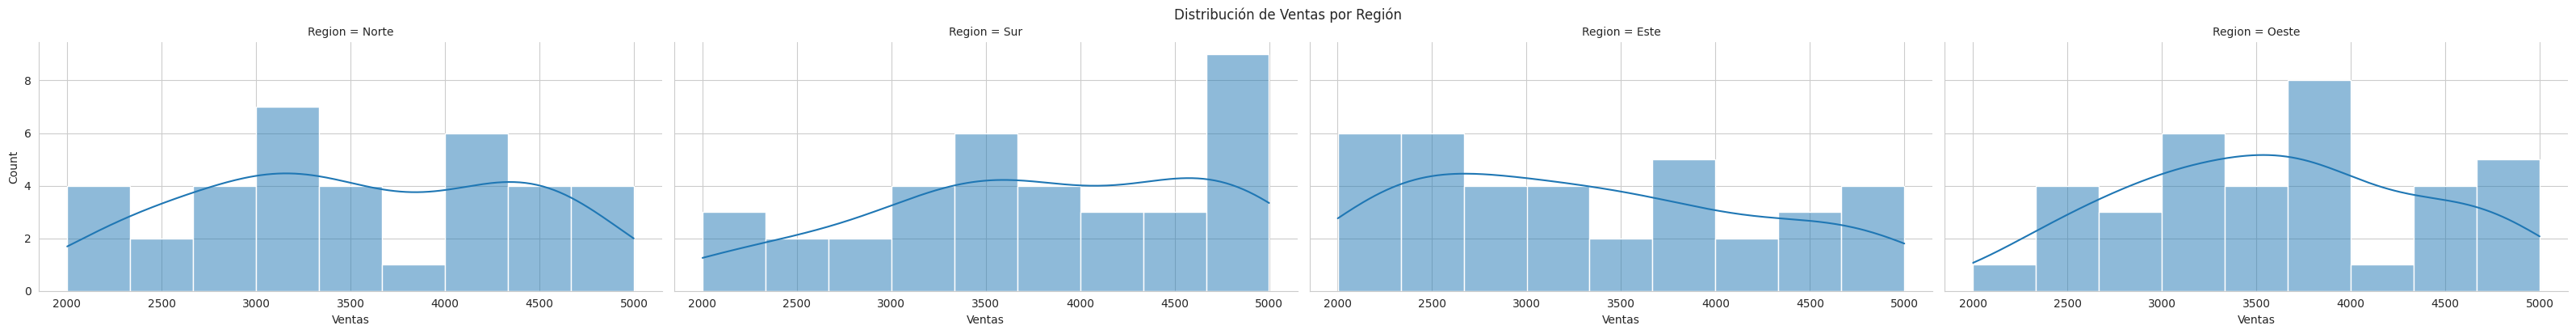

In [ ]:
# Displot: Distribucion de ventas por region
sns.displot(data=df, x='Ventas', col='Region', kde=True, height=4, aspect=2)
plt.suptitle('Distribución de Ventas por Región', y=1.02)
plt.show()


3.2. Gráficos Categóricos (Categorical Plots)

Comparan una variable numérica a través de diferentes categorías.

• barplot: Muestra una estimación puntual (por defecto, la media) y un intervalo de confianza.


• boxplot: Muestra la distribución a través de cuartiles (caja), medianas (línea central) y outliers (puntos).


• violinplot: Combina un boxplot con un KDE plot, mostrando la forma de la distribución.


• countplot: Muestra la cuenta de observaciones en cada categoría (similar a un histograma para variables categóricas).


• catplot: Figura-nivel para gráficos categóricos, permite fácil faceting (col, row, hue, kind).

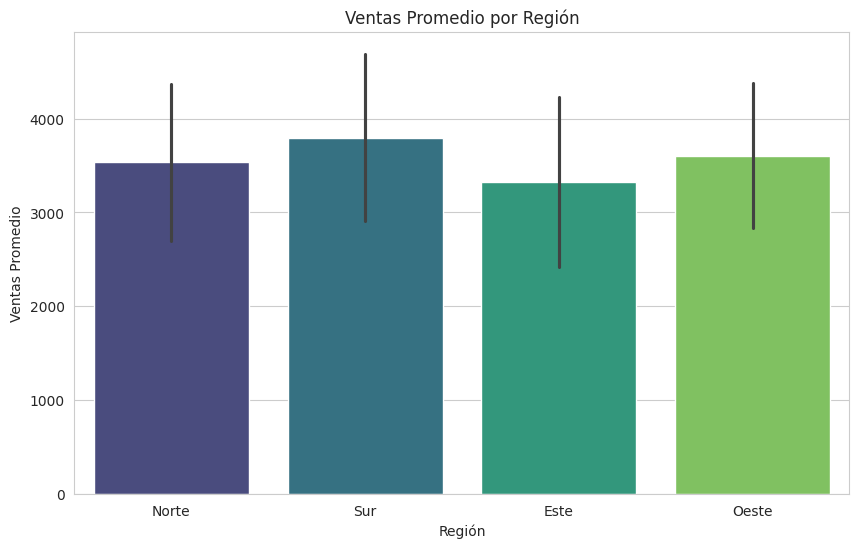

In [ ]:
# Barplot: Ventas promedio por region
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Region', y='Ventas', ci='sd', palette='viridis') # sd muestra la desviacion estandar
plt.title('Ventas Promedio por Región')
plt.xlabel('Región')
plt.ylabel('Ventas Promedio')
plt.show()
#

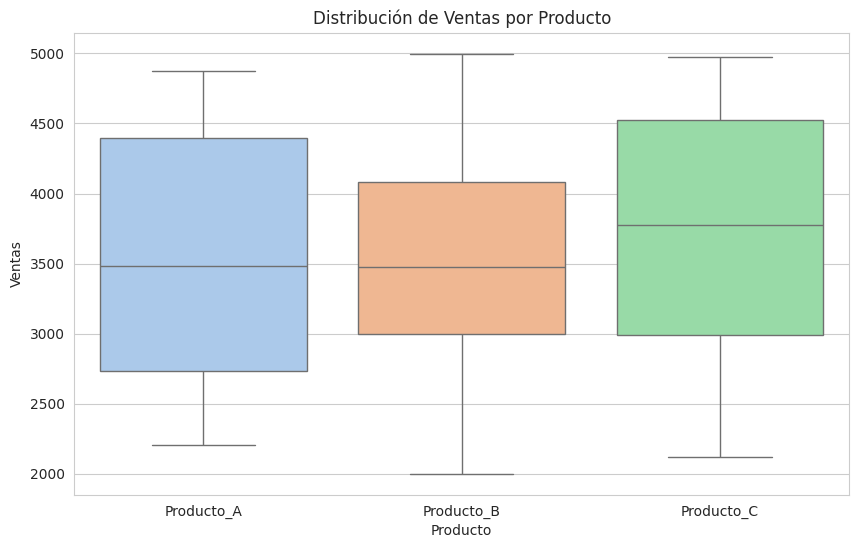

In [ ]:
# Boxplot distribucion de ventas por producto
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Producto', y='Ventas', palette='pastel')
plt.title('Distribución de Ventas por Producto')
plt.xlabel('Producto')
plt.ylabel('Ventas')
plt.show()

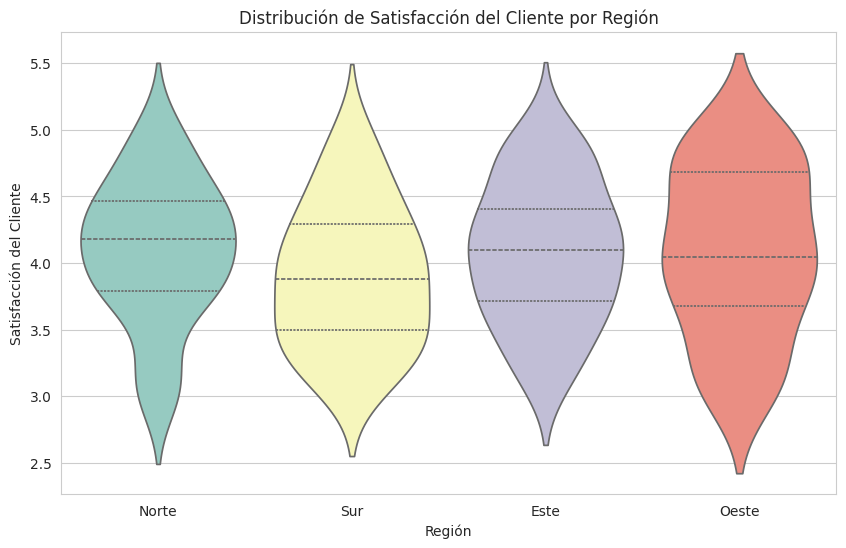

In [ ]:
# Violinplot distribucion de satisfaccion del cliente por region
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Region', y='Satisfaccion_Cliente', palette='Set3', inner='quartile')
plt.title('Distribución de Satisfacción del Cliente por Región')
plt.xlabel('Región')
plt.ylabel('Satisfacción del Cliente')
plt.show()
#

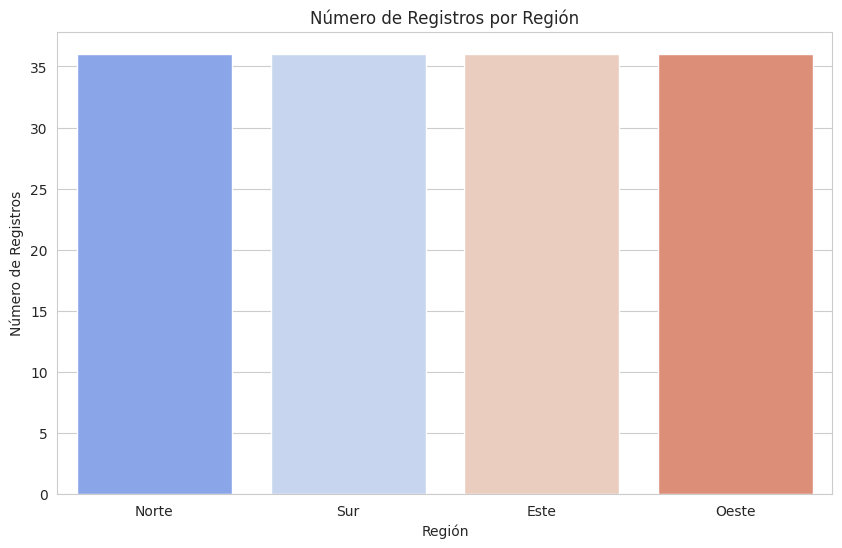

In [ ]:
# Countplot: Numero de registros por region
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Region', palette='coolwarm')
plt.title('Número de Registros por Región')
plt.xlabel('Región')
plt.ylabel('Número de Registros')
plt.show()
#

<Figure size 1200x600 with 0 Axes>

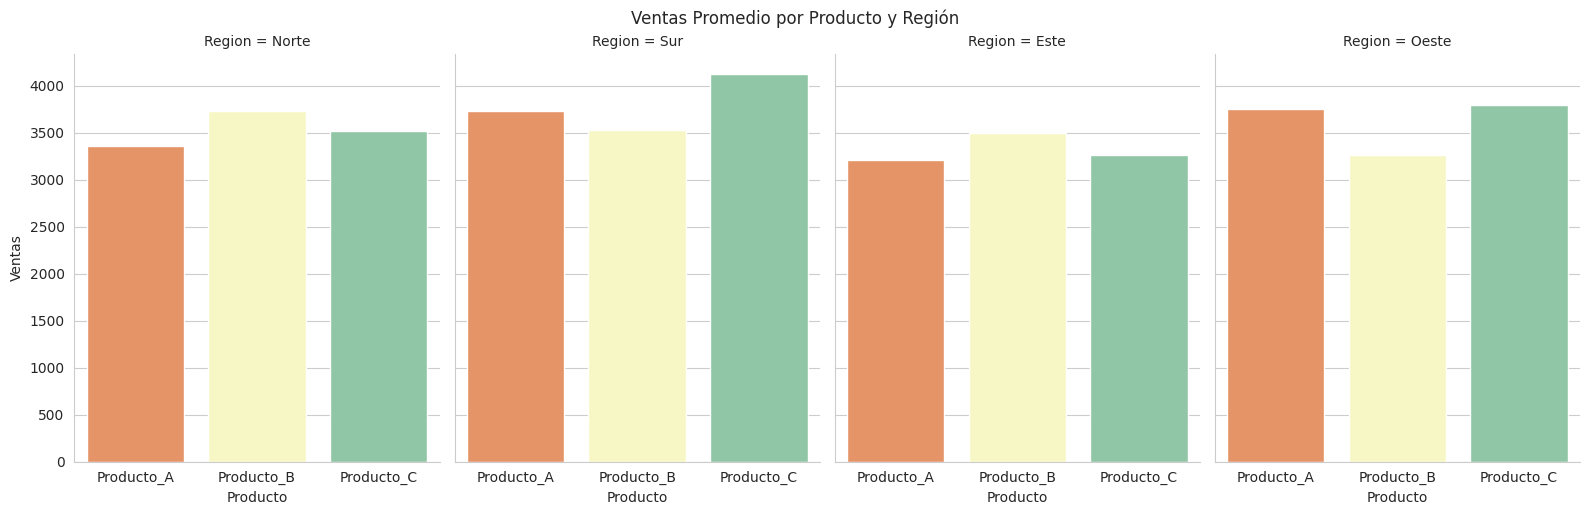

In [ ]:
# Catplot: ventas promedio por producto y region
plt.figure(figsize=(12, 6))
sns.catplot(data=df, x='Producto', y='Ventas', col='Region', kind='bar', height=5, aspect=0.8, palette='Spectral', ci=None)
plt.suptitle('Ventas Promedio por Producto y Región', y=1.02)
plt.show()
#

3.3. Gráficos de Relación (Relational Plots)



Exploran la relación entre dos variables numéricas.



• scatterplot: Muestra la relación entre dos variables numéricas. Se puede añadir información categórica con hue, size, style.



• lineplot: Ideal para visualizar tendencias a lo largo del tiempo o de otra variable continua.



• relplot: Figura-nivel para scatterplots y lineplots, facilita la creación de subgráficos basados en categorías.